## Exploratory Analysis with Self-developed Package, 'DIM'

written by **Jinwoo Lee**            
jil527@ucsd.edu | jinwoo-lee.com

Dec, 2025       
as a PSYC201A's **Reproduction Project**

**Note:** This script aims to explore a multivariate **'psychological profile'** whose intersubject mean matrix is more strongly correlated with the interpersonal dissimilarity matrix of the left vPFC-amygdala morphology than a single measure of trait anxiety. 

For this purpose, we will utilize parts of the **‘DIM’** package, which was custom-developed for the First Year Project. Since **DIM** is part of an ongoing research project in our lab, the corresponding GitHub repository is not publicly available.

---
### Step 1. Loading the Packages

In [1]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.insert(0, '../DIM/src')
from lib.dim.level1 import Level1  # importing our DIM package
from lib.utils.stats import cv_hyperparameter_search
from scipy.spatial.distance import pdist, squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor

---
### Step 2. Preparing Behavioral and Neural Datasets   

#### 2-A. Self-reported measurements
To explore the 'psychological profile' whose mean matrix is strongly associated with the left vPFC-amygdala distance matrix, I will use the following affective characteristics in addition to trait anxiety:   

- emotion regulation strategies (reappraisal and suppression): d’Arbeloff et al., 2018; Eden et al., 2015

- trait neuroticism: Bjørenbekk et al. 2013; Ueda et al., 2018

- trait impulsivitiy: Peper et al., 2013

All of these variables have been reported to explain the variance of the PFC-amygdala structural connectivity and also available in the original LEMON dataset. To use these additional features, I downloaded **`Behavioural_Data_MPILMBB_LEMON`** at [the official download website of the dataset](https://fcon_1000.projects.nitrc.org/indi/retro/MPI_LEMON.html). This script assumes that users have already downloaded this data and located it in the top directory of the workspace.    

In [ ]:
### Load the Rawdata
meta = pd.read_csv('../data-from-authors/Meta.csv')
STAI = pd.read_csv('../data-from-authors/STAI_G_X2.csv') 
ERQ = pd.read_csv('../Behavioural_Data_MPILMBB_LEMON/Emotion_and_Personality_Test_Battery_LEMON/ERQ.csv') 
NEOFFI = pd.read_csv('../Behavioural_Data_MPILMBB_LEMON/Emotion_and_Personality_Test_Battery_LEMON/NEO_FFI.csv') 
UPPS = pd.read_csv('../Behavioural_Data_MPILMBB_LEMON/Emotion_and_Personality_Test_Battery_LEMON/UPPS.csv') 

### Filtering 'Young' Group Samples
# age
youth = meta[meta['Age'].isin(['20-25', '25-30', '30-35'])]

# IDP availability
exclude_subjects = ['sub-032339', 'sub-032341', 'sub-032459', 'sub-032370', 
                    'sub-032466', 'sub-032438', 'sub-032509']
youth = youth[~youth['Unnamed: 0'].isin(exclude_subjects)]

# SKID Diagnoses
youth['SKID_Diagnoses'] = pd.Categorical(youth['SKID_Diagnoses'])
youth['SKID_Diagnoses_numeric'] = youth['SKID_Diagnoses'].cat.codes + 1 
Hyouth = youth[(youth['SKID_Diagnoses_numeric'] == 0) | (youth['SKID_Diagnoses_numeric'] == 10)]

# leaving only relevant info
columns_to_drop = list(range(3, 14)) + list(range(15, 21))  
Hyouth = Hyouth.drop(Hyouth.columns[columns_to_drop], axis=1)

# merging STAI data with Hyouth
Hyouth = pd.merge(Hyouth, STAI, on = 'Unnamed: 0')
Hyouth = pd.merge(Hyouth, ERQ, on = 'Unnamed: 0')
Hyouth = pd.merge(Hyouth, NEOFFI, on = 'Unnamed: 0')
Hyouth = pd.merge(Hyouth, UPPS, on = 'Unnamed: 0')

# IMPORTANT: Matching the order of subjects with brain morphology data
Hyouth = Hyouth.sort_values('Unnamed: 0').reset_index(drop = True) 

# extracting the targeted affective characteristics
target_cols = ['STAI_Trait_Anxiety', 'ERQ_reappraisal', 'ERQ_suppression' , 'NEOFFI_Neuroticism', 'UPPS_lack_perseverance']
X_discovery_df = Hyouth[target_cols]

# confirm that all self-reported measurements do not have any NaN
assert X_discovery_df.isna().sum().sum() == 0
X_discovery = X_discovery_df.values

#### 2-B. Checking multicollinearity of Self-reported Measurements

`DIM` mainly learns weights of self-reported features so that mean matrix of their weighted sum scores can have correlation coefficients with vPFC-amygdala morphology distance matrix as large as possible. However, when these features are highly correlated each other (i.e., high multicollinearity), the convergence of weight prediction becomes highly unstable. For this reason, it is important how large these features show multicollinearity. 

I will use **variance of inflation factor (VIF)** and **correlation heatmaps** as quantitative and qualitative measures of multicollinearity. 

STAI_Trait_Anxiety: VIF = 49.6673
ERQ_reappraisal: VIF = 13.7814
ERQ_suppression: VIF = 12.8888
NEOFFI_Neuroticism: VIF = 20.1240
UPPS_lack_perseverance: VIF = 21.9828


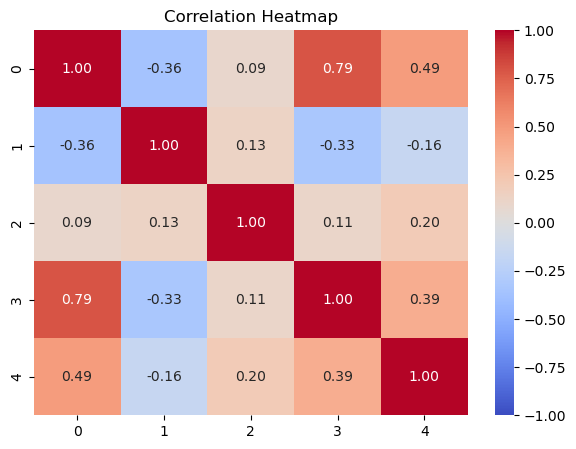

In [4]:
### Varaiance Inflation Factor (VIF) as a quantitative measure of multicollinearity
for i in range(X_discovery_df.shape[1]):
    vif = variance_inflation_factor(X_discovery_df, i)
    print(f"{target_cols[i]}: VIF = {vif:.4f}")

### Correlation Heatmap as a qualitative measure of multicollinearity
corr_plot = np.corrcoef(X_discovery, rowvar = False)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_plot, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title("Correlation Heatmap")
plt.show()

According to the conventional interpretation criteria of VIF, all five variables show **high multicollinearity** (i.e., VIF > 10). Keeping this finding in mind, I will manually set hyperparameters of `DIM` so that my model can handle the multicollinearity issue.


#### 2-C. vPFC-amygdala Morphology Dataset

As done in `03_reproduction-with-ours.ipynb`, I will use `yh_probmap_5p_L.csv` to construct the interpersonal distance matrix of the left vPFC-amygdala morphology. 

In [5]:
# Load the tractography data
yh_prob_5p_L = pd.read_csv('../data-from-authors/tractfiles/yh_probmap_5p_L.csv')
yh_prob_5p_L = yh_prob_5p_L.iloc[:, 1:]  # Remove the first column (index)

# Compute the distance matrix
D_y_discovery = squareform(pdist(yh_prob_5p_L.T, metric = 'euclidean'))

---
### Step 3. Exploratory Data-driven Anna Karenina Modeling with DIM

#### 3-A. Hyperparamater Tuning
We sought to identify the optimal combination of four hyperparameters for model training: learning rate (`lr`), early stopping threshold (`min_delta`), and the ElasticNet regularization terms (`lambda` and `alpha`). 

We employed 5-repeated 3-fold cross-validation on the discovery set. To favor model parsimony and prevent overfitting, the optimal configuration was selected using the one-standard-error rule (Hastie et al., 2008). A total of 81 combinations were explored within the following search space: `lr` $\in [.001, .005, .01]$, `min_delta` $\in [.0001, .0005, .001]$, `lambda` $\in [.001, .01, .1]$, and `alpha` $\in [0, .25, .50]$. The selected optimal parameters were: `lr` $= .01$, `min_delta` $= .0005$, `lambda` $= .1$, and `alpha` $= .50$.

> **[NOTE]** Because the model needs to be trained each time a hyperparameter combination is evaluated, this process requires substantial computational resources. In our case, it took approximately **6.5 hours**. 

In [ ]:
### Define Search Space
param_grid = {
        'lambda_omega': [1e-3, 1e-2, 1e-1],
        'alpha_elastic': [0.0, 0.25, 0.50],
        'lr': [1e-3, 5e-3, 1e-2],
        'min_delta': [1e-4, 5e-4, 1e-3]
        }

### Fixed Parameters
fixed_params = {
    'model': 'AnnaK',
    'distance': 'Mean',
    'weighting': 'Learn',
    'dependency': 'spearman_r',
    'max_iters': 1000,
    'verbose': False,
    'patience': 10,
    'normalize': True,
    'temperature': 0.1,
    }

cv_result = cv_hyperparameter_search(
    X_discovery, D_y_discovery, Level1, param_grid, fixed_params,
    n_folds = 3, n_repeats = 5, seed = 42)

Grid search: 81 combinations × 5 repeats × 3 folds = 1215 fits


Grid search: 100%|██████████| 81/81 [6:41:37<00:00, 297.50s/comb]  


Grid search completed in 24097.3s
Max rule: {'lambda_omega': 0.01, 'alpha_elastic': 0.0, 'lr': 0.001, 'min_delta': 0.0001} (mean r = 0.1814)
1SE rule: {'lambda_omega': 0.1, 'alpha_elastic': 0.5, 'lr': 0.01, 'min_delta': 0.0005} (mean r = 0.1781)


#### 3-B. Model Training
Using the optimal hyperparameters, we applied the weight learning mode of `DIM` to the discovery set ($X_{\text{discovery}}$, $D_{y, \text{discovery}}$) to identify the composite score mean matrix that maximizes correlation with the morphological dissimilarity matrix.

In [ ]:
### Defining the Model (using default hyperparameters without tuning)
AnnaK_model = Level1(
    model = "AnnaK",
    distance = "Mean",
    weighting = "Learn",
    dependency = "spearman_r",
    normalize = True,
    max_iters = 1000,
    lr = cv_result['best_params_1se']['lr'], 
    min_delta = cv_result['best_params_1se']['min_delta'], 
    patience = 10,
    lambda_omega = cv_result['best_params_1se']['lambda_omega'], 
    alpha_elastic = cv_result['best_params_1se']['alpha_elastic'],
    temperature = 0.1,
    seed = 42,
    verbose = True
)

### Fitting the Model
AnnaK_model.fit(X_discovery, D_y_discovery)

### Conducting Permutation Test for Calculating P-value
mantel_result = AnnaK_model.permutation_test_discovery(
    n_perms = 500,
    verbose = True,
    return_null_dist = True,
    seed = 42
)

mantel_result

Validation successful!
Starting weight learning...
[Iter: 0010/1000] Loss: 0.0383 | Dependence: 0.1741
[Iter: 0020/1000] Loss: -0.0186 | Dependence: 0.1857
[Iter: 0030/1000] Loss: -0.0682 | Dependence: 0.2045
[Iter: 0040/1000] Loss: -0.1126 | Dependence: 0.2289
[Iter: 0050/1000] Loss: -0.1548 | Dependence: 0.2526
[Iter: 0060/1000] Loss: -0.1927 | Dependence: 0.2672
[Iter: 0070/1000] Loss: -0.2223 | Dependence: 0.2751
[Iter: 0080/1000] Loss: -0.2433 | Dependence: 0.2774
[Iter: 0090/1000] Loss: -0.2550 | Dependence: 0.2757
[Iter: 0100/1000] Loss: -0.2662 | Dependence: 0.2772
[Iter: 0110/1000] Loss: -0.2677 | Dependence: 0.2722
[Iter: 0120/1000] Loss: -0.2725 | Dependence: 0.2780
Early stopping at epoch 122


/Users/jinwoolee/Documents/github/kim2024/code/../DIM/src/lib/dim/level1.py:708: UserWarning: Discovery test with weighting='Learn' is an in-sample test and may overestimate significance. Always validate findings using permutation_test_replication() on independent test data.
  warnings.warn(
Permutation test (refitting): 100%|██████████| 500/500 [3:40:34<00:00, 26.47s/perm]  


{'observed_stat': 0.2781170904636383,
 'p_value': np.float64(0.048),
 'n_perms': 500,
 'null_mean': np.float64(0.18109756211936473),
 'null_std': np.float64(0.05642703216930788),
 'computation_time': 13263.921209096909,
 'null_distribution': array([0.18816508, 0.16873042, 0.06825255, 0.14959353, 0.15122125,
        0.08804147, 0.16451782, 0.23196037, 0.17289528, 0.13312384,
        0.21472049, 0.14940347, 0.30229127, 0.28264639, 0.09545111,
        0.1489173 , 0.1718464 , 0.15800634, 0.08500648, 0.21482052,
        0.20181063, 0.22353859, 0.16233002, 0.15290894, 0.11948358,
        0.23269808, 0.20143144, 0.20203102, 0.12986839, 0.05193007,
        0.17621799, 0.29186359, 0.22353022, 0.29432616, 0.23048261,
        0.16013199, 0.18191765, 0.15681359, 0.16402911, 0.10797049,
        0.11375431, 0.23378381, 0.16158469, 0.11178156, 0.16880912,
        0.25300655, 0.11107987, 0.09250711, 0.21722765, 0.18141258,
        0.17850652, 0.13023618, 0.25745201, 0.09303827, 0.17086433,
        0.1

Here, compared to a single trait anxiety measure ($\rho$ = .148), I found the **affective profile score** whose interpersonal mean matrix is more strongly associated with the interpersonal distance matrix of the left vPFC-amygdala morphology ($\rho$ = .278). 

Critically, a posterior power analysis revealed that this finding **reached at the conventional power threshold 80%, 0.92, unlike the original paper**. This means that my data-driven `DIM` can discover more *'powerful'* scientific findings than the conventional Anna Karenina model testing.     

Then, how can this **affective profile** be interpreted? 


#### 3-C. Inference of feature weights
One of the intutive appraoches for interpretation is to figure out how large weights each variable has in the model. To evaluate the stability and statistical significance of the learned weights for the five features, we performed bootstrapping with 500 iterations. In each iteration, subjects were resampled with replacement to generate new input matrices, and the model was retrained. Significance was determined based on the 95% confidence intervals (CIs) of the weights; a weight was considered significant if its CI did not include zero. 

STAI_Trait_Anxiety: w = 0.0113
ERQ_reappraisal: w = 0.0024
ERQ_suppression: w = 0.0299
NEOFFI_Neuroticism: w = 0.0321
UPPS_lack_perseverance: w = -0.0269


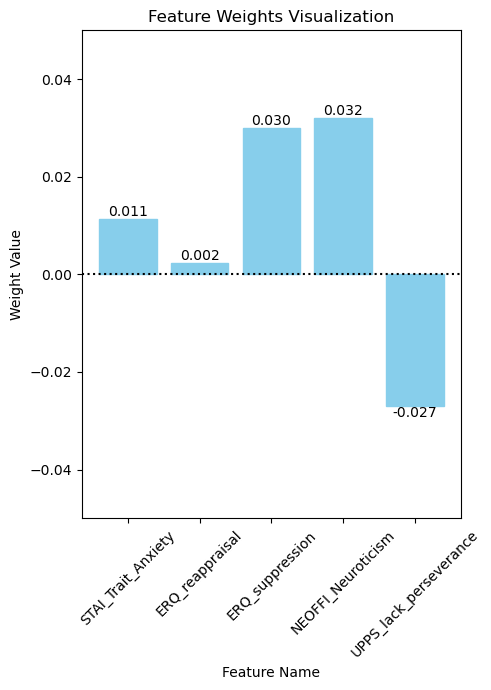

In [9]:
feature_weights = AnnaK_model.weights_

for i in range(len(feature_weights)):
    print(f"{target_cols[i]}: w = {feature_weights[i]:.4f}")

plt.figure(figsize=(5, 7))
plt.bar(target_cols, feature_weights, color='skyblue', edgecolor='skyblue')
plt.ylim(-0.05, 0.05)
plt.axhline(0, color='black', linestyle=':', linewidth=1.5)

plt.ylabel("Weight Value")
plt.xlabel("Feature Name")
plt.title("Feature Weights Visualization")

for x, y in zip(target_cols, feature_weights):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom' if y > 0 else 'top')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
boot = AnnaK_model.bootstrap_weights(n_bootstrap = 500,
                                     confidence_level = 0.95,
                                     seed = 42,
                                     verbose = True)

Bootstrap weights: 100%|██████████| 500/500 [3:31:03<00:00, 25.33s/iter]  


In [17]:
boot

{'weights_observed': array([ 0.01126871,  0.00237041,  0.02993309,  0.03206283, -0.0269103 ],
       dtype=float32),
 'weights_mean': array([ 0.01783849,  0.00536971,  0.05652704,  0.05090186, -0.03623076],
       dtype=float32),
 'weights_std': array([0.04464736, 0.03551411, 0.06002001, 0.05072788, 0.04420418],
       dtype=float32),
 'ci_lower': array([-0.06684575, -0.06596369,  0.00329754, -0.00739853, -0.1538447 ],
       dtype=float32),
 'ci_upper': array([0.11892325, 0.07130735, 0.2529937 , 0.20455787, 0.02745838],
       dtype=float32),
 'n_bootstrap': 500,
 'n_successful': 500,
 'confidence_level': 0.95,
 'computation_time': 12685.594018936157,
 'model_type': 'AnnaK',
 'significance_threshold': 0.0,
 'significant': array([False, False,  True, False, False])}

We found that especially **emotion suppression** strongly and significantly construct the affective profile associated with individual differences in the left vPFC-amygdala pathway morphology. This means that when individuals have high levels of emotion suppression, their vPFC-amygdala pathway would be more 'idiosyncratic'. Their engagement was stronger than a single measure of trait anxiety alone. 

---
### Step 4. Generalizability Testing
To assess the generalizability of the identified model, we applied the trained weights to the independent replication set ($X_{\text{replicate}}$, $D_{y, \text{replicate}}$) without further optimization. We evaluated the model's performance by calculating Spearman’s $\rho$ and assessing its statistical significance via a Mantel permutation test (10,000 iterations). In each permutation, the indices of $D_{y, \text{replicate}}$ were randomly shuffled, and the pre-trained model was applied to the shuffled data to approximate the null distribution of Spearman’s $\rho$. The p-value was calculated as the proportion of null statistics exceeding the observed $\rho$.

#### 4-A. Preparation of Replicate Set

In [ ]:
### Filtering Older Group Samples
# age
senior = meta[meta['Age'].isin(['60-65', '65-70', '70-75'])]

# IDP availability
senior_exclude_subjects = ["sub-032339", "sub-032341", "sub-032459", "sub-032370",
                           "sub-032466", "sub-032438", "sub-032509", "sub-032392", "sub-032443", "sub-032488"]
senior = senior[~senior['Unnamed: 0'].isin(senior_exclude_subjects)]

# SKID Diagnoses
senior['SKID_Diagnoses'] = pd.Categorical(senior['SKID_Diagnoses'])
senior['SKID_Diagnoses_numeric'] = senior ['SKID_Diagnoses'].cat.codes + 1 

Hsenior = senior[(senior['SKID_Diagnoses_numeric'] == 5) | (youth['SKID_Diagnoses_numeric'] == 6)]

# leaving only relevant info
Hsenior = Hsenior.drop(Hsenior.columns[columns_to_drop], axis=1)

# merging STAI data with Hsenior
Hsenior = pd.merge(Hsenior, STAI, on = 'Unnamed: 0')
Hsenior = pd.merge(Hsenior, ERQ, on = 'Unnamed: 0')
Hsenior = pd.merge(Hsenior, NEOFFI, on = 'Unnamed: 0')
Hsenior = pd.merge(Hsenior, UPPS, on = 'Unnamed: 0')

# IMPORTANT: Matching the order of subjects with brain morphology data
Hsenior = Hsenior.sort_values('Unnamed: 0').reset_index(drop = True)

X_test = Hsenior[target_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype='float32')
oh_prob_5p_L = pd.read_csv('../data-from-authors/tractfiles/oh_prob_5p_L_new.csv')
oh_prob_5p_L = oh_prob_5p_L.iloc[:, 1:]  # Remove the first column (index)

D_y_test = squareform(pdist(oh_prob_5p_L.T, metric = 'euclidean'))

/var/folders/pk/pd0z53jd7rb6v8r41_lcv3tm0000gp/T/ipykernel_41263/4144040797.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Hsenior = senior[(senior['SKID_Diagnoses_numeric'] == 5) | (youth['SKID_Diagnoses_numeric'] == 6)]


#### 4-B. Model Evaluation

In [16]:
test_result = AnnaK_model.permutation_test_replication(X_test, D_y_test, n_perms = 10000, seed = 42, verbose = True)
test_result

Permutation test: 100%|██████████| 10000/10000 [00:44<00:00, 225.74perm/s]


{'observed_stat': 0.3186796307563782,
 'p_value': np.float64(0.0107),
 'n_perms': 10000,
 'alternative': 'greater',
 'null_mean': np.float64(0.0023422709252949063),
 'null_std': np.float64(0.1380579983300879),
 'null_distribution': array([-0.11609662, -0.02370332,  0.09751602, ...,  0.03205486,
        -0.0798956 ,  0.01948725], shape=(10000,)),
 'train_stat': 0.2781170904636383,
 'effect_size_ratio': 1.1458469892127794}

--- 
For visualizing the scatterplot between mean composite score and brain morphological dissimilarity value, we saved all the data from the exploratory analysis

In [ ]:
### discovery set
discovery_D_x = AnnaK_model.get_Dx()
discovery_idx = np.triu_indices(discovery_D_x.shape[0], k = 1)
discovery_D_x_vec = discovery_D_x[discovery_idx]
discovery_D_y_vec = D_y_discovery[discovery_idx]

df_discovery = pd.DataFrame({'comp_mean': discovery_D_x_vec, 'brain_dissimilarity': discovery_D_y_vec})

### weights and their CIs
df_weights_bool = pd.DataFrame({'weight_estimates': feature_weights, 
                                'weight_ci_lower': boot['ci_lower'],
                                'weight_ci_upper': boot['ci_upper']})

### replicate set
replicate_D_x = AnnaK_model.get_Dx(X_test)
replicate_idx = np.triu_indices(replicate_D_x.shape[0], k = 1)
replicate_D_x_vec = replicate_D_x[replicate_idx]
replicate_D_y_vec = D_y_test[replicate_idx]

df_replicate = pd.DataFrame({'comp_mean': replicate_D_x_vec, 'brain_dissimilarity': replicate_D_y_vec})

### null distribution from permutation tests
df_null = pd.DataFrame({'null_rho': test_result['null_distribution']})

### Saving the files
df_discovery.to_csv('results/exploratory/discovery_vectors.csv', index = False)
df_weights_bool.to_csv('results/exploratory/discovery_boot_weights.csv', index = False)
df_replicate.to_csv('results/exploratory/replicate_vectors.csv', index = False)
df_null.to_csv('results/exploratory/replicate_null_distribution.csv', index = False)